In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm



In [2]:
from scipy.stats import chi2_contingency
from scipy import stats
def check_chi_square(df, col1, col2):
    """
    Hàm kiểm tra tính độc lập giữa 2 biến phân loại bằng Chi-Square.
    Nhằm phát hiện đa cộng tuyến phân loại.
    """
    # 1. Lập bảng tần suất chéo (Contingency Table) giữa 2 biến
    contingency_table = pd.crosstab(df[col1], df[col2])
    
    # 2. Chạy kiểm định Chi-Square
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table) # 
    
    # 3. In kết quả trực quan
    print(f"--- KIỂM ĐỊNH CHI-SQUARE: [{col1}] & [{col2}] ---")
    print(f"Giá trị thống kê χ² : {chi2_stat:.4f}")
    print(f"p-value             : {p_value:.4f}") # In ra p-value của kiểm định


def filter_by_anova_eta(df, cat_col, target_col):
    """
    Sử dụng kiểm định ANOVA và chỉ số Eta-squared (η²).
    """
    # Lọc bỏ các dòng có giá trị NaN ở 2 cột đang xét để hàm không bị lỗi
    valid_data = df[[cat_col, target_col]].dropna()
    
    # 1. CHUẨN BỊ DỮ LIỆU CHO ANOVA
    # Tách biến mục tiêu thành các mảng (arrays) riêng biệt theo từng nhóm phân loại
    groups = [group[target_col].values for name, group in valid_data.groupby(cat_col)]
    
    # 2. CHẠY KIỂM ĐỊNH ANOVA
    f_stat, p_value = stats.f_oneway(*groups)
    
    # 3. TÍNH TOÁN ETA-SQUARED (η²)
    # Tính trung bình của toàn bộ biến mục tiêu
    mean_total = valid_data[target_col].mean()
    
    # Tính Sum of Squares Total (SST)
    ss_total = ((valid_data[target_col] - mean_total) ** 2).sum()
    
    # Tính Sum of Squares Between (SSB)
    ss_between = 0
    for name, group in valid_data.groupby(cat_col):
        ss_between += len(group) * ((group[target_col].mean() - mean_total) ** 2)
        
    # Công thức Eta-squared
    eta_squared = ss_between / ss_total
    
    # 4. TRÌNH BÀY KẾT QUẢ
    print(f"--- ĐÁNH GIÁ BIẾN: [{cat_col}] tác động lên [{target_col}] ---")
    
    # In p-value (dùng định dạng số mũ e nếu quá nhỏ để tránh hiển thị 0.0000)

    print(f"p-value (ANOVA)  : {p_value:.4f} ")
    
    # In Eta-squared
    print(f"Eta-squared (η²) : {eta_squared:.4f}")


In [3]:
file_path = 'data/Walmart.csv'
df = pd.read_csv(file_path)

In [4]:
df.head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,12-03-2010,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,19-03-2010,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,26-03-2010,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,02-04-2010,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,09-04-2010,1545418.53,0,65.86,2.770,210.622857,7.808


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 465.2 KB


In [6]:
print("--- Tỉ lệ dữ liệu khuyết thiếu (NaN) trên từng cột ---")
nan_ratio = df.isnull().mean()
print(nan_ratio)
print("-" * 50)

--- Tỉ lệ dữ liệu khuyết thiếu (NaN) trên từng cột ---
Store           0.0
Date            0.0
Weekly_Sales    0.0
Holiday_Flag    0.0
Temperature     0.0
Fuel_Price      0.0
CPI             0.0
Unemployment    0.0
dtype: float64
--------------------------------------------------


In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.weekday

In [8]:
df.head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Weekday
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,4
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,4
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,4
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,4
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,4
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,4
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,4
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,4
8,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010,4,4
9,1,2010-04-09,1545418.53,0,65.86,2.770,210.622857,7.808,2010,4,4


In [9]:
print(df['Store'].value_counts().count())
print(df['Holiday_Flag'].value_counts().count())
print(df['Month'].value_counts().count())
print(df['Weekday'].value_counts().count())
print(df['Year'].value_counts().count())

45
2
12
1
3


- Dữ liệu thu thu thập mỗi thứ tư hàng tuần

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Weekday       6435 non-null   int32         
dtypes: datetime64[us](1), float64(5), int32(3), int64(2)
memory usage: 477.7 KB


## Phân tích biến liên tục

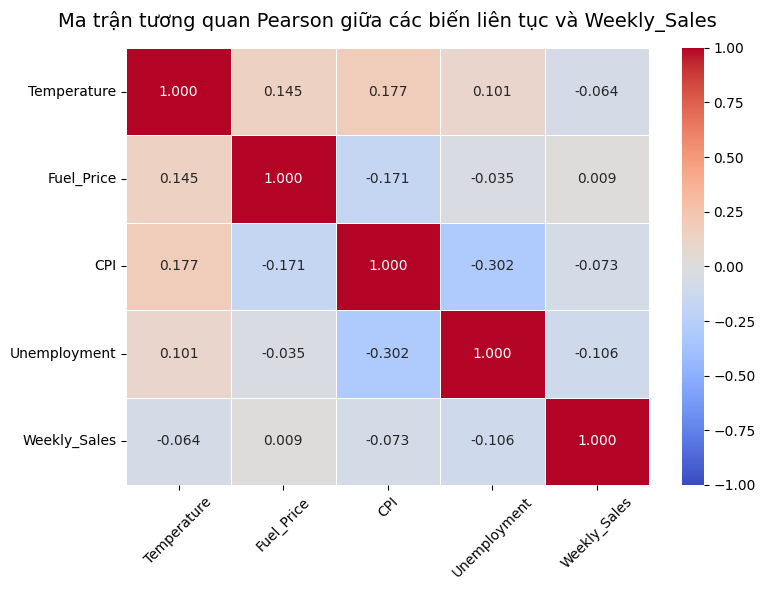

In [11]:
# 1. Xác định danh sách các biến liên tục và biến mục tiêu
continuous_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
target = 'Weekly_Sales'

# Gom tất cả vào một danh sách chung để tính ma trận tương quan
cols_to_corr = continuous_features + [target]

# 2. Tính toán ma trận tương quan Pearson từ DataFrame (df)
corr_matrix = df[cols_to_corr].corr()

# 3. Tiến hành cấu hình và vẽ biểu đồ Heatmap
plt.figure(figsize=(8, 6))

# Vẽ heatmap với các cấu hình tối ưu:
# - annot=True: Hiển thị giá trị số trên từng ô vuông
# - cmap='coolwarm': Bảng màu từ xanh (tương quan âm) sang đỏ (tương quan dương)
# - fmt=".3f": Làm tròn lấy 3 chữ số sau dấu phẩy
# - vmin=-1, vmax=1: Cố định dải màu chuẩn của hệ số tương quan từ -1 đến 1
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)

# Thay đổi tiêu đề và cách hiển thị
plt.title('Ma trận tương quan Pearson giữa các biến liên tục và Weekly_Sales', fontsize=14, pad=15)
plt.xticks(rotation=45) # Xoay chữ trục hoành để không bị đè chữ
plt.yticks(rotation=0)  # Giữ chữ trục tung nằm ngang cho dễ đọc

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

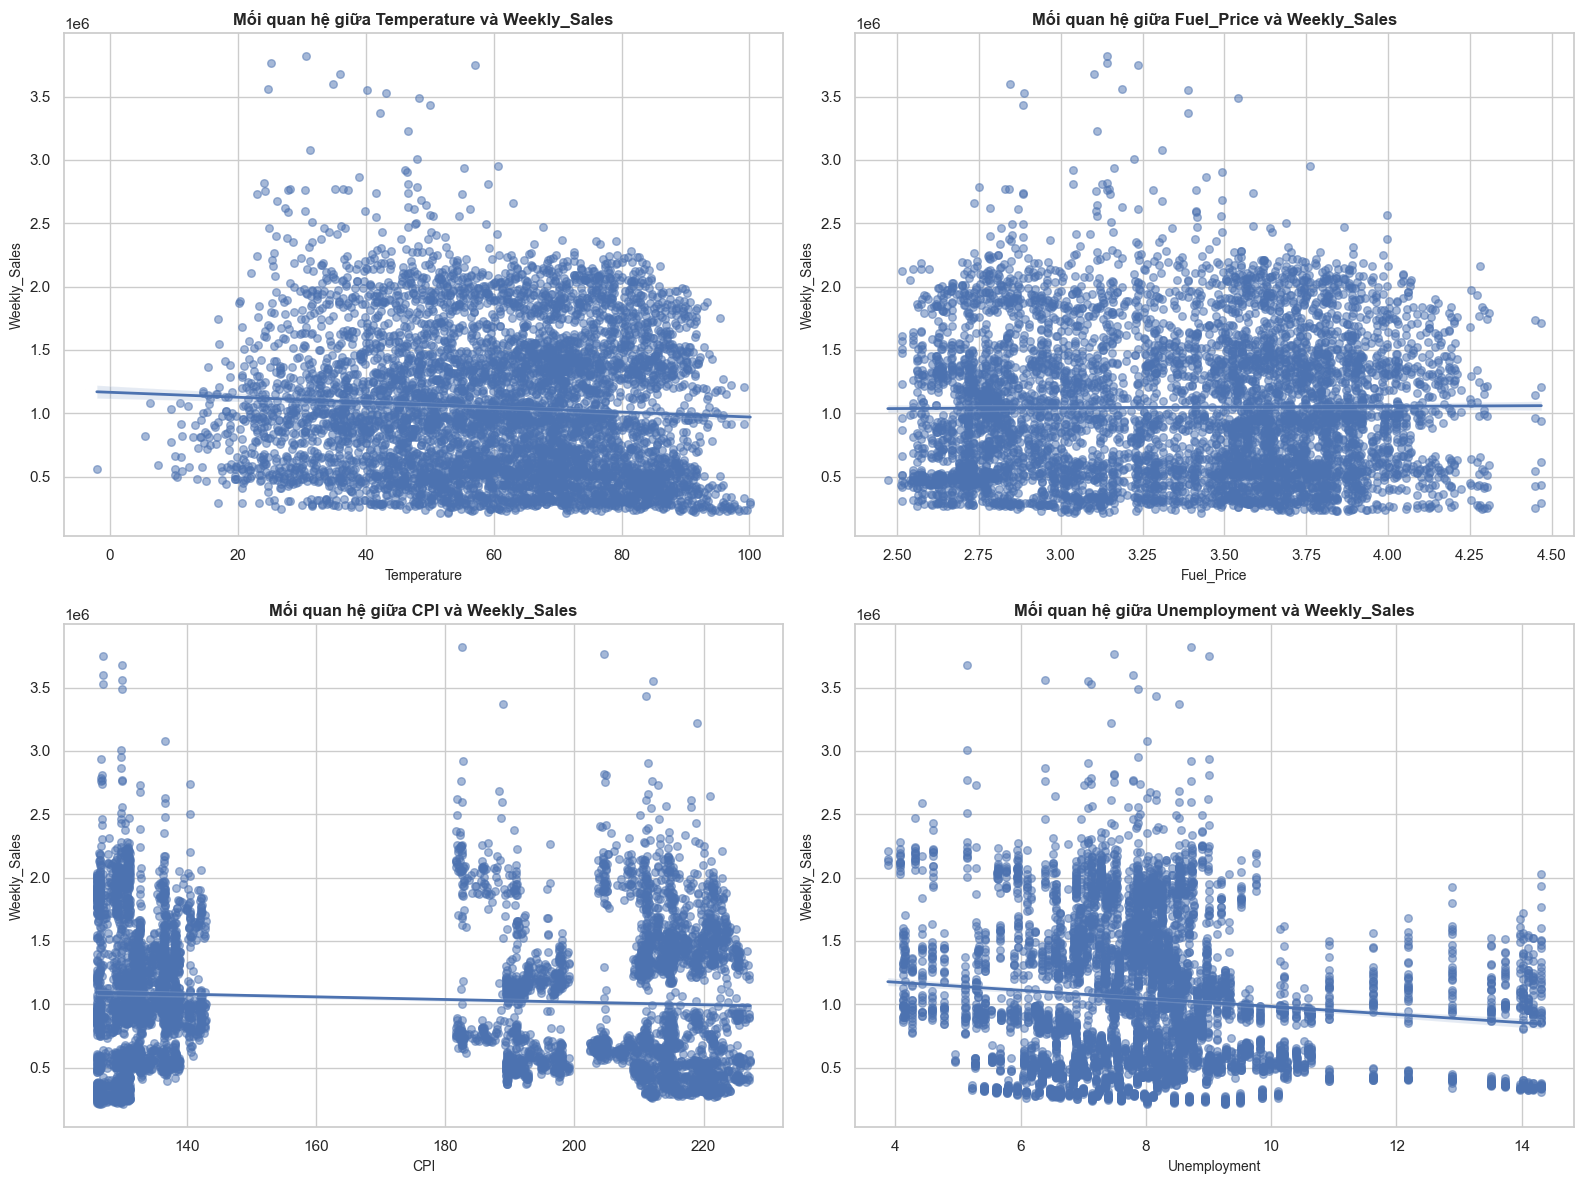

In [12]:
# 1. Định nghĩa danh sách các biến theo yêu cầu của bạn
continuous_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
target = 'Weekly_Sales'

# 2. Thiết lập cấu hình thẩm mỹ cho đồ thị
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# 3. Vòng lặp tự động vẽ biểu đồ cho từng biến vào lưới 2x2
for i, feature in enumerate(continuous_features):
    # Xác định vị trí dòng và cột trong lưới 2x2
    row = i // 2
    col = i % 2
    
    # Vẽ Scatter Plot kèm đường xu hướng hồi quy
    sns.regplot(
        data=df, 
        x=feature, 
        y=target, 
        ax=axes[row, col],
        scatter_kws={'alpha': 0.5, 's': 30},  # Độ trong suốt và kích thước điểm
        line_kws={'linewidth': 2}              # Độ dày của đường xu hướng
    )
    
    # Thêm tiêu đề và nhãn cho từng biểu đồ con
    axes[row, col].set_title(f'Mối quan hệ giữa {feature} và {target}', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel(feature, fontsize=10)
    axes[row, col].set_ylabel(target, fontsize=10)

# 4. Tối ưu khoảng cách giữa các biểu đồ để không bị đè chữ
plt.tight_layout()
plt.show()

- Phân tích 2 Biểu đồ ta thấy được : Các biến liên tục trong bộ dữ liệu hiện tại không có mối quan hệ với biến mục tiêu

In [13]:
X = df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']] # Chỉ còn 1 biến thỏa điều kiện (Các biến còn lại chỉ gây nhiễu)
X = sm.add_constant(X) # Thêm hằng số hệ số chặn 
y = df['Weekly_Sales']

# Khớp mô hình hồi quy tuyến tính bình phương tối thiểu (OLS)
model = sm.OLS(y, X).fit()

print("="*80)
print("TÓM TẮT KẾT QUẢ MÔ HÌNH HỒI QUY:")
print(model.summary())
print("="*80)

TÓM TẮT KẾT QUẢ MÔ HÌNH HỒI QUY:
                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     40.09
Date:                Fri, 29 May 2026   Prob (F-statistic):           3.21e-33
Time:                        21:45:10   Log-Likelihood:                -94273.
No. Observations:                6435   AIC:                         1.886e+05
Df Residuals:                    6430   BIC:                         1.886e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1

## Khi xét thêm về mặt ý nghĩa của các biến liên tục : Ho là Biến độc lập không liên quan đến biến mục tiêu
- Temperature, CPI ,   Unemployment  có p-value < 0.05 => Bác bỏ Ho => vẫn có giá trị        

## Phân tích biến phân loại

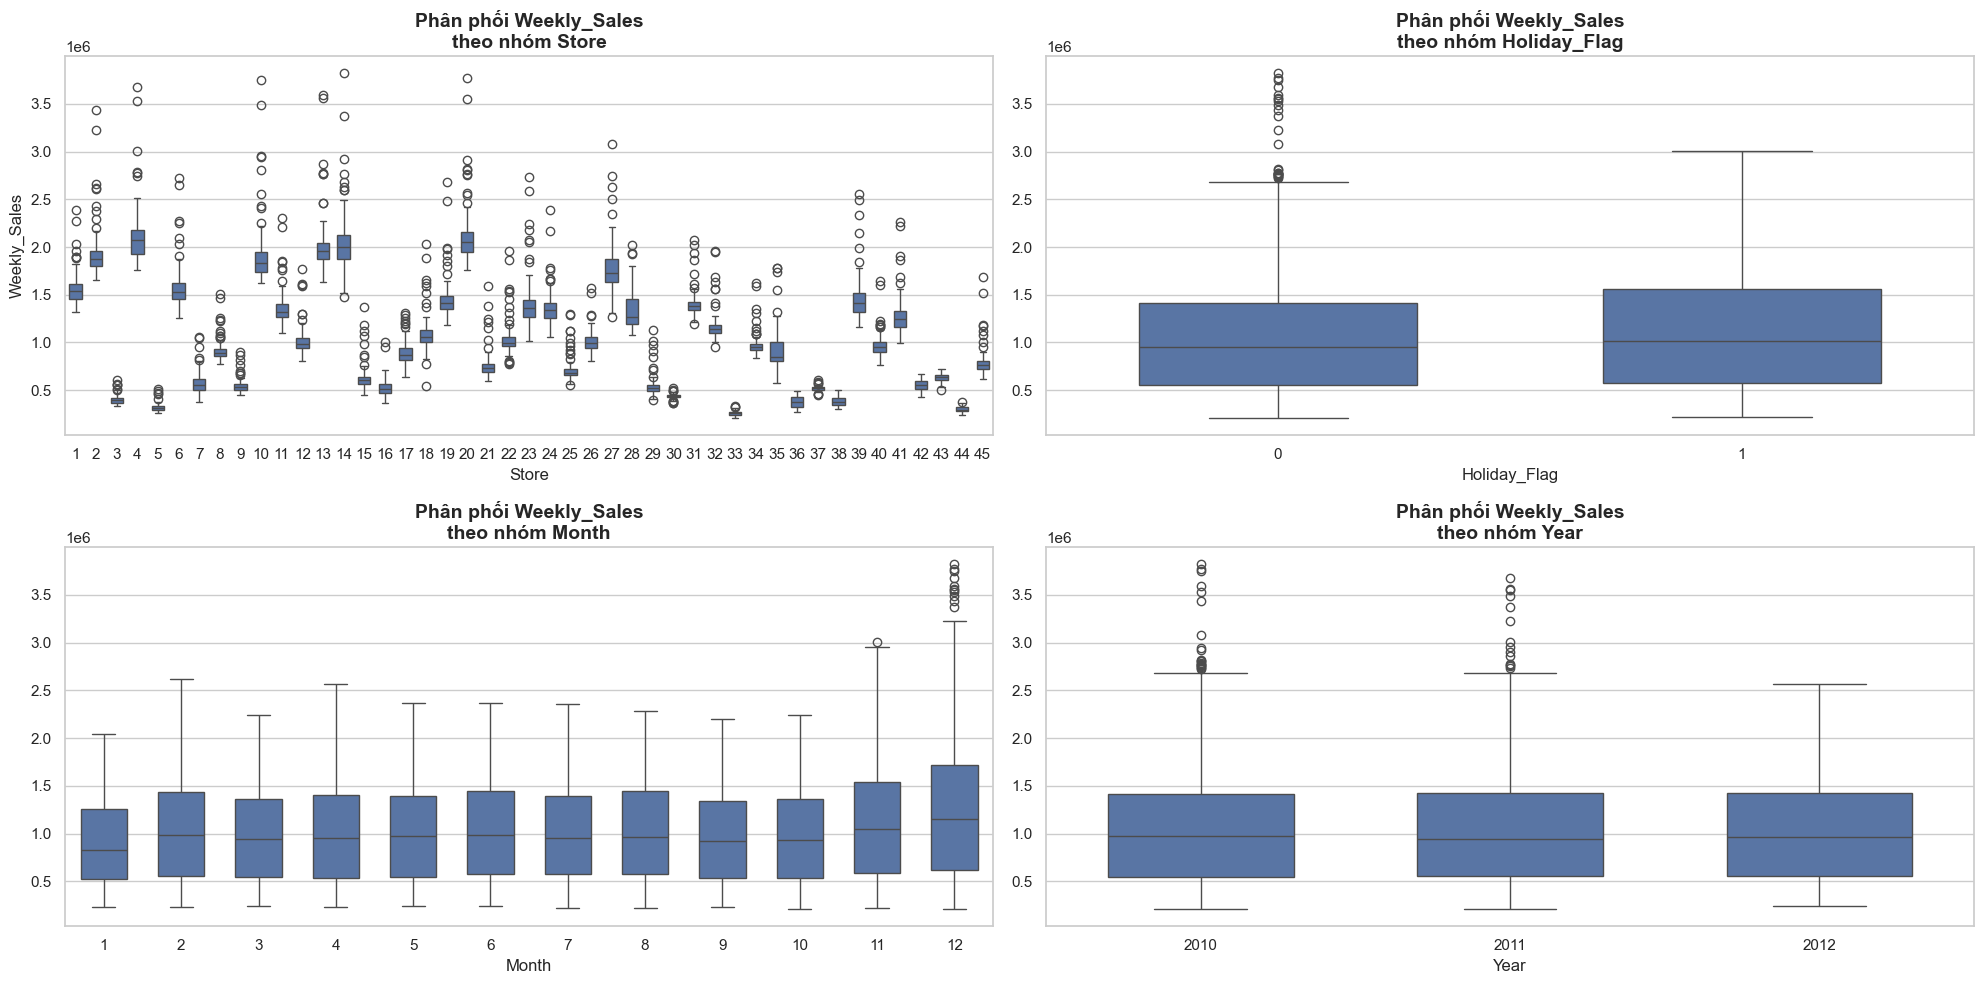

In [14]:

# Danh sách các biến phân loại cần vẽ (đã xác định là độc lập ở Bước 2)
cat_cols = ['Store', 'Holiday_Flag', 'Month',  'Year']

# Định dạng thẩm mỹ cho biểu đồ
sns.set_theme(style="whitegrid") # Nền trắng có lưới
plt.figure(figsize=(20, 10))      # Thiết lập kích thước khung tranh tổng thể (Rộng, Cao)

# Lặp qua từng biến phân loại để vẽ biểu đồ con (subplot)
for i, col in enumerate(cat_cols, 1):
    # Tạo subplot: 2 hàng, 3 cột, vị trí thứ i
    ax = plt.subplot(2, 2, i)
    
    # Vẽ Boxplot
    # x: Biến phân loại (nhóm)
    # y: Biến mục tiêu (số)
    sns.boxplot(x=col, y=target, data=df, width=0.6)
    
    
    # Trang trí cho từng biểu đồ con
    ax.set_title(f'Phân phối {target}\ntheo nhóm {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel(target if i == 1 else "", fontsize=12) # Chỉ hiện nhãn trục Y ở biểu đồ đầu tiên

# Tự động căn chỉnh khoảng cách giữa các biểu đồ để không bị đè chữ
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

In [15]:
for col in cat_cols:
    filter_by_anova_eta(df, col, target)

--- ĐÁNH GIÁ BIẾN: [Store] tác động lên [Weekly_Sales] ---
p-value (ANOVA)  : 0.0000 
Eta-squared (η²) : 0.9174
--- ĐÁNH GIÁ BIẾN: [Holiday_Flag] tác động lên [Weekly_Sales] ---
p-value (ANOVA)  : 0.0031 
Eta-squared (η²) : 0.0014
--- ĐÁNH GIÁ BIẾN: [Month] tác động lên [Weekly_Sales] ---
p-value (ANOVA)  : 0.0000 
Eta-squared (η²) : 0.0188
--- ĐÁNH GIÁ BIẾN: [Year] tác động lên [Weekly_Sales] ---
p-value (ANOVA)  : 0.3373 
Eta-squared (η²) : 0.0003


## Ho : Biến độc lập không liên quan đến biến mục tiêu
- Store, Holiday_Flag, Month có p-value <> 0.05 => Bác bỏ Ho => 3 Biến này có liên quan đến biến mục tiêu
- Year có p-value > 0.05 => Không bác bỏ Ho => Biến này không liên quan đến biến mục tiêu
## Xét Eta-squared đo lường tỷ lệ phần trăm sự biến thiên của Weekly_Sales được giải thích bởi biến phân loại.
- Store rất tốt. 
- Holiday_Flag và Month có ý nghĩa với biến mục tiêu nhưng về mặt giải thích thì rât yếu

In [16]:
import itertools

cat_cols_2 = ['Store', 'Holiday_Flag', 'Month']

for col1, col2 in itertools.combinations(cat_cols_2, 2):
    check_chi_square(df, col1, col2)

--- KIỂM ĐỊNH CHI-SQUARE: [Store] & [Holiday_Flag] ---
Giá trị thống kê χ² : 0.0000
p-value             : 1.0000
--- KIỂM ĐỊNH CHI-SQUARE: [Store] & [Month] ---
Giá trị thống kê χ² : 0.0000
p-value             : 1.0000
--- KIỂM ĐỊNH CHI-SQUARE: [Holiday_Flag] & [Month] ---
Giá trị thống kê χ² : 1136.7694
p-value             : 0.0000


## Ho : Hai biến không liên quan nhau
- Holiday_Flag với Month có p-value < 0.05 => Bác bỏ Ho => 2 biến đang có liên quan nhau
- Holiday_Flag có (η²) = 0.0014 < Month = 0.0188 => Bỏ Holiday_Flag

## Huấn luyện mô hình 

In [17]:
# df_new = df[['Store', 'Month', 'Temperature', 'CPI', 'Unemployment', 'Weekly_Sales']].copy() #  0.938,0.937  MAE: 86,376.63
# df_new = df[['Store', 'Month',  'Unemployment', 'Weekly_Sales']].copy() #  0.938,0.937    MAE : 86,348.31
# df_new = df[['Store', 'Month',  'Weekly_Sales']].copy() #   0.938,  0.937    MAE : 87,287.59
df_new = df[['Store','Holiday_Flag', 'Month',  'Year',  'Unemployment', 'Weekly_Sales']].copy() #  0.938, 0.938    MAE :  85,999.44

# =====================================================================
# BƯỚC 1: TẠO BIẾN GIẢ VÀ THIẾT LẬP BIẾN CƠ SỞ (QUY TẮC k-1)
# =====================================================================
# drop_first=True tự động bỏ đi Store đầu tiên và Month đầu tiên làm mốc cơ sở
df_encoded = pd.get_dummies(df_new, columns=['Store', 'Month'], drop_first=True, dtype=int)


In [ ]:

# Tách đặc trưng (X) và mục tiêu (y)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, r2_score

X = df_encoded.drop(columns=['Weekly_Sales'])
y = df_encoded['Weekly_Sales']

# BẮT BUỘC: Thêm cột hằng số (constant) để tính hệ số chặn Intercept (Beta 0)
X_with_const = sm.add_constant(X)

# Lấy nhãn Store gốc để chia tầng phân bổ đều
store_labels = df_new['Store'].values

# =====================================================================
# BƯỚC 2: CẤU HÌNH STRATIFIED K-FOLD (CHIA ĐỀU STORE)
# =====================================================================
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

mae_scores = []
r2_scores = []

print(f"--- BẮT ĐẦU CHẠY OLS VỚI {n_splits}-FOLD CROSS VALIDATION ---\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X_with_const, store_labels), 1):
    
    # Chia dữ liệu theo chỉ số dòng đã phân tầng
    X_train, X_test = X_with_const.iloc[train_idx], X_with_const.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # -----------------------------------------------------------------
    # BƯỚC 3: HUẤN LUYỆN MÔ HÌNH OLS
    # -----------------------------------------------------------------
    # Lưu ý cú pháp của statsmodels: sm.OLS(y, X) ngược với scikit-learn
    ols_model = sm.OLS(y_train, X_train).fit()
    
    # Dự đoán trên tập kiểm thử của Fold hiện tại
    y_pred = ols_model.predict(X_test)
    
    # Đánh giá hiệu suất
    fold_mae = mean_absolute_error(y_test, y_pred)
    fold_r2 = r2_score(y_test, y_pred)
    
    mae_scores.append(fold_mae)
    r2_scores.append(fold_r2)
    
    print(f"Fold {fold}: R² = {fold_r2:.4f} | MAE = {fold_mae:,.2f}")
    
    # In bảng báo cáo chi tiết cho Fold cuối cùng để bạn xem phân tích hệ số
    if fold == n_splits:
        print("\n" + "="*30 + " BẢNG BÁO CÁO CHI TIẾT OLS (FOLD CUỐI) " + "="*30)
        print(ols_model.summary())
        print("="*99)

# =====================================================================
# BƯỚC 4: TỔNG HỢP HIỆU SUẤT TRUNG BÌNH
# =====================================================================
print("\n" + "="*50)
print("KẾT LUẬN HIỆU SUẤT TRUNG BÌNH QUA CÁC FOLDS:")
print(f"-> R² Trung bình  : {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})")
print(f"-> MAE Trung bình : {np.mean(mae_scores):,.2f}")
print("="*50)

--- BẮT ĐẦU CHẠY OLS VỚI 5-FOLD CROSS VALIDATION ---

Fold 1: R² = 0.9376 | MAE = 84,469.93
Fold 2: R² = 0.9386 | MAE = 85,684.49
Fold 3: R² = 0.9365 | MAE = 89,189.01
Fold 4: R² = 0.9352 | MAE = 84,978.13
Fold 5: R² = 0.9319 | MAE = 85,675.62

============================== BẢNG BÁO CÁO CHI TIẾT OLS (FOLD CUỐI) ==============================
                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     1338.
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        11:10:28   Log-Likelihood:                -68295.
No. Observations:                5148   AIC:                         1.367e+05
Df Residuals:                    5089   BIC:                         1.371e+05
Df Model:              

In [ ]:
# Xem Độ lệch chuẩn để đánh giá tính ổn định của mô hình qua các folds
print(f"R² trung bình: {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})")
print(f"MAE trung bình: {np.mean(mae_scores):,.2f} (+/- {np.std(mae_scores):,.2f})")

R² trung bình: 0.9360 (+/- 0.0023)
MAE trung bình: 85,999.44 (+/- 1,658.91)


In [ ]:
final_ols_model = sm.OLS(y, X_with_const).fit() ## Cẫn xét thêm đa cộng tuyến tổng thể 

In [ ]:
latest_date = df['Date'].max()
print(f"Ngày cuối cùng trong tập dữ liệu: {latest_date.strftime('%d-%m-%Y')}")
print(df[df['Date'] == latest_date].head())

Ngày cuối cùng trong tập dữ liệu: 26-10-2012
     Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
142      1 2012-10-26    1493659.74             0        69.16       3.506   
285      2 2012-10-26    1834458.35             0        69.79       3.506   
428      3 2012-10-26     405432.70             0        74.66       3.506   
571      4 2012-10-26    2149594.46             0        63.64       3.514   
714      5 2012-10-26     319550.77             0        71.70       3.506   

            CPI  Unemployment  Year  Month  Weekday  
142  223.444251         6.573  2012     10        4  
285  223.078337         6.170  2012     10        4  
428  226.987364         6.034  2012     10        4  
571  131.193097         3.879  2012     10        4  
714  224.037814         5.422  2012     10        4  


In [ ]:
# 1. Khai báo thông tin thô của ngày cần dự đoán
future_df = pd.DataFrame({
    'Store': [1],
    'Date': [pd.to_datetime('2012-10-26')],
    'Unemployment': [6.573]
})

# Trích xuất thông tin tháng từ cột Date (Ngày 02/11/2012 -> Tháng 11)
future_df['Month'] = future_df['Date'].dt.month

# 2. Khởi tạo ma trận X_future trống có các cột và thứ tự giống hệt X_with_const khi train
X_future = pd.DataFrame(0.0, index=[0], columns=X_with_const.columns)

# 3. Điền giá trị hệ số chặn Intercept (Luôn luôn là 1.0)
X_future['const'] = 1.0

# 4. Điền giá trị của các biến liên tục có trong mô hình
X_future['Unemployment'] = future_df['Unemployment'].values[0]

# 5. KÍCH HOẠT BIẾN GIẢ (ONE-HOT ENCODING) CHO STORE VÀ MONTH
# Store cần dự đoán là 20 -> Tên cột tương ứng trong ma trận là 'Store_20'
target_store_col = f"Store_{future_df['Store'].values[0]}"
# Month cần dự đoán là 11 -> Tên cột tương ứng trong ma trận là 'Month_11'
target_month_col = f"Month_{future_df['Month'].values[0]}"

# Bật tín hiệu số 1 cho các cột Store và Month tương ứng (nếu chúng tồn tại trong tập Train)
if target_store_col in X_future.columns:
    X_future[target_store_col] = 1.0

if target_month_col in X_future.columns:
    X_future[target_month_col] = 1.0

# =====================================================================
# BƯỚC 5: TIẾN HÀNH DỰ ĐOÁN GIÁ TRỊ THỰC TẾ
# =====================================================================
future_df['Predicted_Weekly_Sales'] = final_ols_model.predict(X_future)

print("\n--- KẾT QUẢ DỰ ĐOÁN DOANH SỐ CHO DỮ LIỆU TƯƠNG LAI ---")
print(future_df[['Store', 'Date', 'Unemployment', 'Predicted_Weekly_Sales']])


--- KẾT QUẢ DỰ ĐOÁN DOANH SỐ CHO DỮ LIỆU TƯƠNG LAI ---
   Store       Date  Unemployment  Predicted_Weekly_Sales
0      1 2012-10-26         6.573            2.567714e+07


In [ ]:
print(f'{future_df["Predicted_Weekly_Sales"].values[0]:,.2f}')

25,677,143.97
